--- [1] Memuat Data ---
Format UTF-8 gagal, mencoba encoding alternatif (Latin-1)...
Dataset berhasil dimuat!
Ukuran Data: (18492, 33)
Data bersih dan siap dianalisis.

--- [2] Membuat Visualisasi (EDA) ---


/tmp/ipython-input-3312126901.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='genre', data=df, order=df['genre'].value_counts().index, palette='viridis')


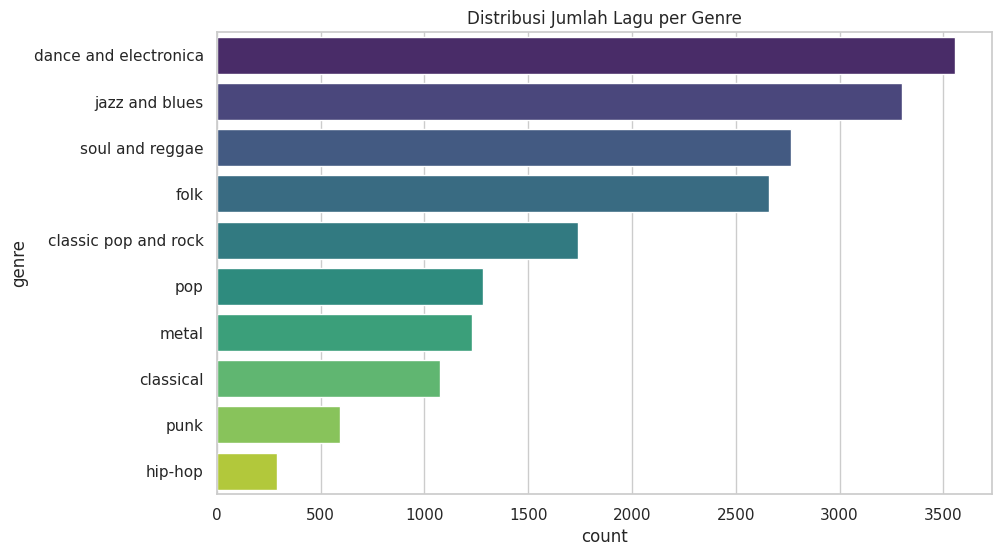

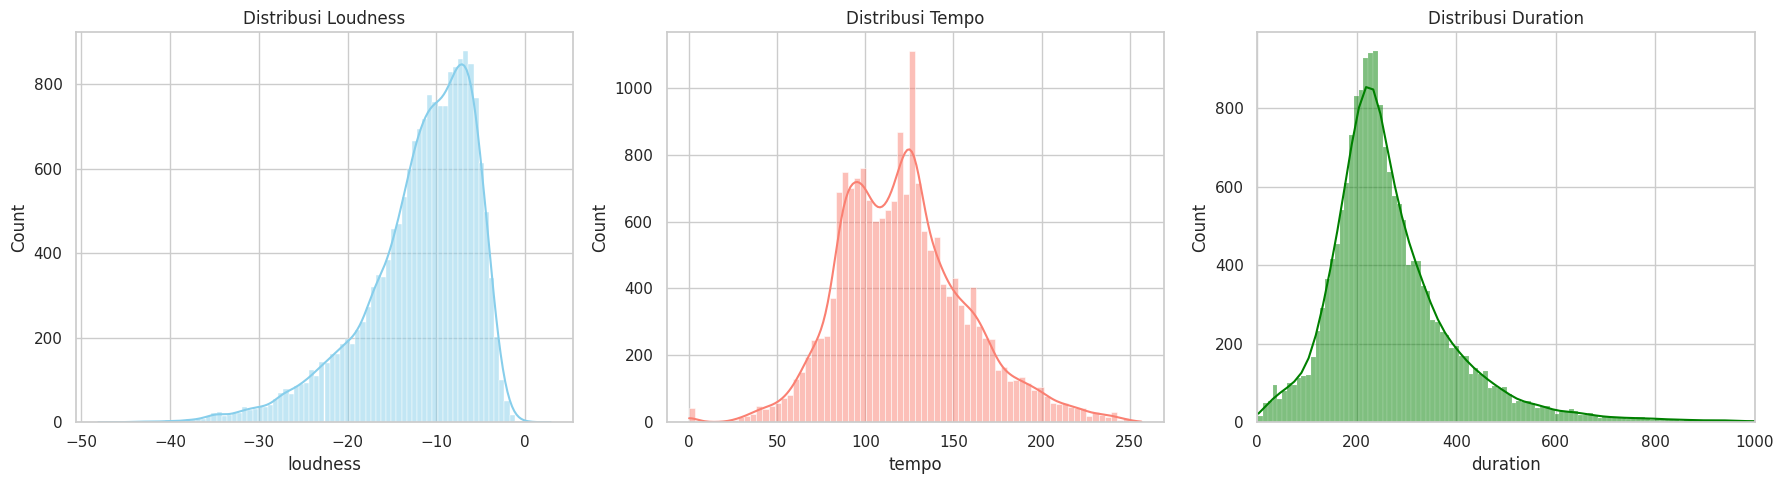

/tmp/ipython-input-3312126901.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='loudness', y='genre', data=df, order=df['genre'].value_counts().index, palette='Set2')


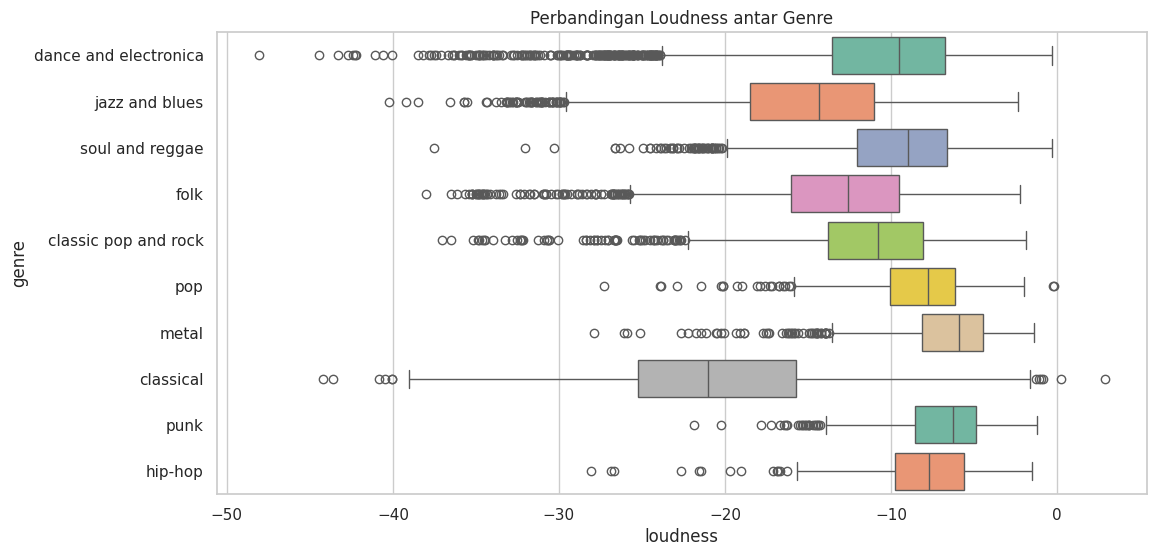


--- [3] Pengujian Hipotesis ---
1. Uji ANOVA (Loudness antar Genre):
   F-statistic: 753.21
   P-value: 0.0
   KESIMPULAN: Terdapat perbedaan SIGNIFIKAN loudness antar genre.

2. Uji Korelasi Pearson (Loudness vs Tempo):
   Correlation Coefficient: 0.1731
   P-value: 2.202668313548773e-124
   KESIMPULAN: Terdapat korelasi SIGNIFIKAN antara Tempo dan Loudness.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ==========================================
# 1. MEMUAT DAN MEMBERSIHKAN DATA (PERBAIKAN)
# ==========================================
print("--- [1] Memuat Data ---")

try:
    df = pd.read_csv('musicgenre-small.csv', sep=';')
except UnicodeDecodeError:
    print("Format UTF-8 gagal, mencoba encoding alternatif (Latin-1)...")
    df = pd.read_csv('musicgenre-small.csv', sep=';', encoding='latin-1')
except FileNotFoundError:
    print("ERROR: File tidak ditemukan. Pastikan sudah upload file csv ke Colab!")
    raise

print("Dataset berhasil dimuat!")

cols_to_convert = ['loudness', 'tempo', 'duration'] + \
                  [f'avg_timbre{i}' for i in range(1, 13)] + \
                  [f'var_timbre{i}' for i in range(1, 13)]

for col in cols_to_convert:
    if col in df.columns and df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.replace(',', '.').astype(float)

print(f"Ukuran Data: {df.shape}")
print("Data bersih dan siap dianalisis.\n")

# ==========================================
# 2. ANALISIS DATA EKSPLORATIF (EDA)
# ==========================================
print("--- [2] Membuat Visualisasi (EDA) ---")
sns.set(style="whitegrid")

# A. Distribusi Genre
plt.figure(figsize=(10, 6))
sns.countplot(y='genre', data=df, order=df['genre'].value_counts().index, palette='viridis')
plt.title('Distribusi Jumlah Lagu per Genre')
plt.show()

# B. Distribusi Numerik (Loudness, Tempo, Duration)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['loudness'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribusi Loudness')
sns.histplot(df['tempo'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribusi Tempo')
sns.histplot(df['duration'], kde=True, ax=axes[2], color='green')
axes[2].set_title('Distribusi Duration')
axes[2].set_xlim(0, 1000)
plt.tight_layout()
plt.show()

# C. Boxplot Genre vs Loudness
plt.figure(figsize=(12, 6))
sns.boxplot(x='loudness', y='genre', data=df, order=df['genre'].value_counts().index, palette='Set2')
plt.title('Perbandingan Loudness antar Genre')
plt.show()

# ==========================================
# 3. PENGUJIAN HIPOTESIS (STATISTIK)
# ==========================================
print("\n--- [3] Pengujian Hipotesis ---")

# Uji 1: ANOVA (Apakah Loudness berbeda antar Genre?)
genres = df['genre'].unique()
loudness_groups = [df[df['genre'] == g]['loudness'] for g in genres]
f_stat, p_value_anova = stats.f_oneway(*loudness_groups)

print(f"1. Uji ANOVA (Loudness antar Genre):")
print(f"   F-statistic: {f_stat:.2f}")
print(f"   P-value: {p_value_anova}")
if p_value_anova < 0.05:
    print("   KESIMPULAN: Terdapat perbedaan SIGNIFIKAN loudness antar genre.")
else:
    print("   KESIMPULAN: Tidak ada perbedaan signifikan.")

# Uji 2: Korelasi Pearson (Loudness vs Tempo)
corr_coef, p_value_corr = stats.pearsonr(df['loudness'], df['tempo'])

print(f"\n2. Uji Korelasi Pearson (Loudness vs Tempo):")
print(f"   Correlation Coefficient: {corr_coef:.4f}")
print(f"   P-value: {p_value_corr}")
if p_value_corr < 0.05:
    print("   KESIMPULAN: Terdapat korelasi SIGNIFIKAN antara Tempo dan Loudness.")
else:
    print("   KESIMPULAN: Tidak ada korelasi signifikan.")